# Dynamic analysis in zebrafish neural crest development

This tutorial provides a step-by-step workflow for analyzing transcriptional dynamics in our newly sequenced zebrafish Smart-seq3 dataset, focused on neural crest cell development. Leveraging state-of-the-art tools such as `scvelo` [[Bergen *et al*., 2020](https://www.nature.com/articles/s41587-020-0591-3), [La Manno *et al*., 2018](https://www.nature.com/articles/s41586-018-0414-6)] and `cellrank` [[Lange *et al*., 2022](https://www.nature.com/articles/s41592-021-01346-6), [Weiler *et al*., 2024](https://www.nature.com/articles/s41592-024-02303-9), [Reuter *et al*., 2019](https://pubs.aip.org/aip/jcp/article/150/17/174103/198585/Generalized-Markov-modeling-of-nonreversible)], this guide centers on the use of the `regvelo` package to model RNA velocity with gene regulatory priors.

We walk through the complete pipeline, from data preprocessing to model training and transcription factor perturbation analysis. The goal is to uncover key regulators and dynamic processes shaping neural crest development, providing a reproducible framework for applying `regvelo` to similar single-cell transcriptomics studies.

### Library import

In [16]:
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import torch
import anndata as ad

import cellrank as cr
import scvi

import mplscience
import matplotlib.pyplot as plt
import seaborn as sns

from regvelo import REGVELOVI
import regvelo as rgv

In [3]:
scvi.settings.seed = 0

Seed set to 0


In [4]:
scv.settings.verbosity = 3
cr.settings.verbosity = 2

In [5]:
%matplotlib inline

In [6]:
plt.rcParams["svg.fonttype"] = "none"
scv.settings.set_figure_params("scvelo", dpi=100, transparent=True, fontsize=14, color_map="viridis")

### Define functions and constants

In [7]:
from anndata import AnnData
from typing import Sequence

### Load data

In [8]:
adata = rgv.datasets.zebrafish_nc()
prior_net = rgv.datasets.zebrafish_grn()
TF_list = adata.var_names[adata.var["is_tf"]].tolist()

try downloading from url
https://drive.google.com/uc?id=1Nzq1F6dGw-nR9lhRLfZdHOG7dcYq7P0i&export=download
... this may take a while but only happens once
creating directory data/zebrafish_nc/ for saving data


100%|█████████████████████████████████████████████████████| 40.2M/40.2M [00:12<00:00, 3.49MB/s]


In [9]:
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=50)
scv.pp.moments(adata)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:13)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


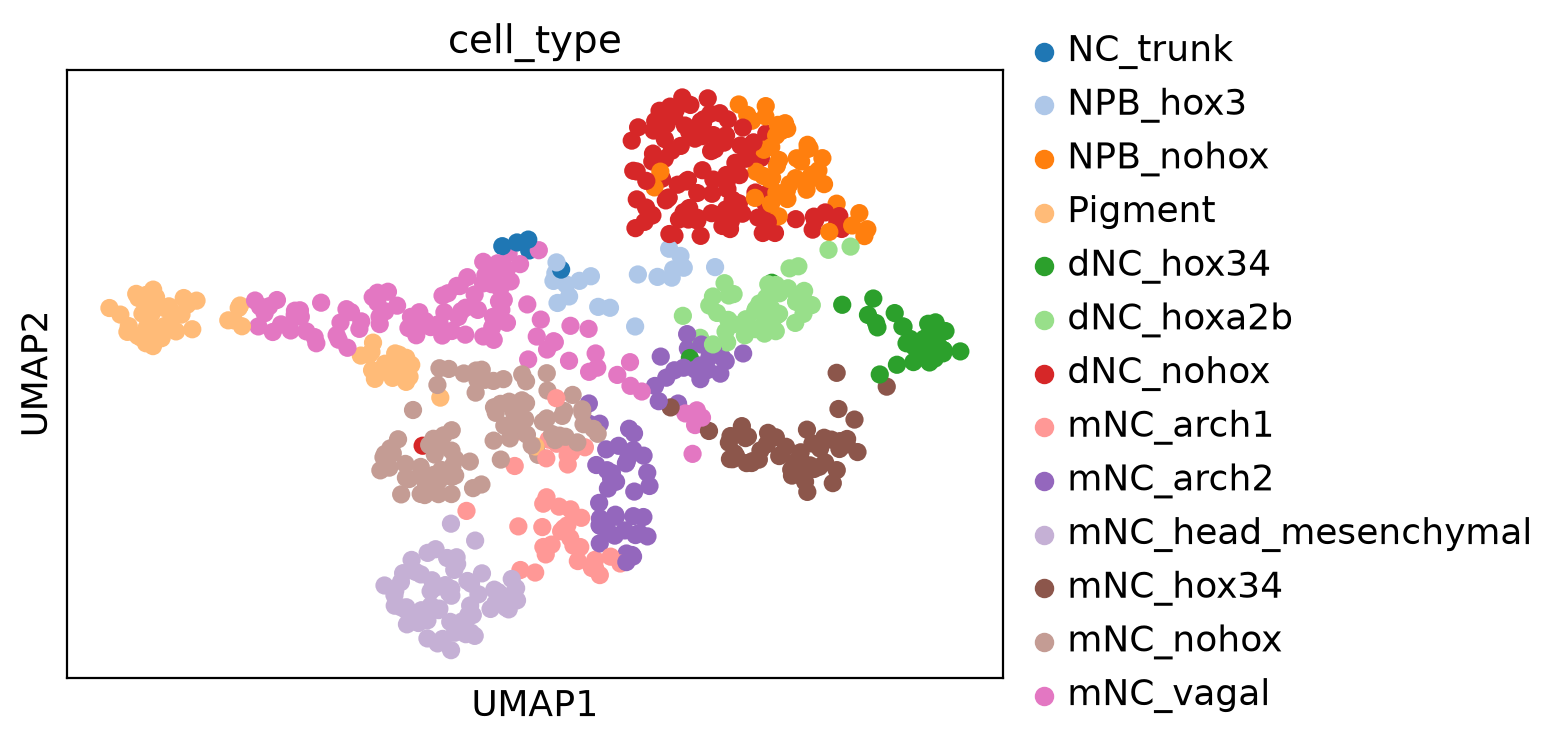

In [10]:
sc.pl.umap(adata, color='cell_type', palette=sc.pl.palettes.vega_20)

### Preprocessing

In [11]:
adata = rgv.pp.preprocess_data(adata)
adata = rgv.pp.set_prior_grn(adata, prior_net.T)

computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [12]:
TF_list = set(TF_list).intersection(adata.var_names)
TF_list = list(TF_list)
print("final number of TFs: " + str(len(TF_list)))

final number of TFs: 81


In [13]:
W = adata.uns["skeleton"].copy()
W = torch.tensor(np.array(W))

In [14]:
sparsity = W.sum() / ((W.sum(1) != 0).sum() * W.shape[0])
print("network sparsity: " + str(np.array(sparsity)))

network sparsity: 0.052775327


## Train RegVelo model

In [15]:
REGVELOVI.setup_anndata(adata, spliced_layer="Ms", unspliced_layer="Mu")
reg_vae = REGVELOVI(adata, W=W.T, regulators=TF_list, soft_constraint=False)

In [16]:
reg_vae.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100 80GB PCIe') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/icb/yifan.chen/miniconda3/envs/regvelo-py310-v2/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/home/icb/yifan.chen/miniconda3/envs/regvelo-py310-v2/lib/python3.10/site-packag

Training:   0%|          | 0/1500 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: -2377.829. Signaling Trainer to stop.


In [17]:
adata = reg_vae.add_regvelo_outputs_to_adata(adata=adata)
scv.tl.velocity_graph(adata)

computing velocity graph (using 1/128 cores)


  0%|          | 0/697 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


### Predict terminal states

In [17]:
adata = ad.read_h5ad("adata_regvelo_zebrafish.h5ad")

Computing transition matrix using `'deterministic'` model


100%|██████████████████████████████████████████████████████| 697/697 [00:08<00:00, 85.92cell/s]

Using `softmax_scale=10.0432`



100%|████████████████████████████████████████████████████| 697/697 [00:00<00:00, 1456.09cell/s]

    Finish (0:00:08)
Computing Schur decomposition


Adding `adata.uns['eigendecomposition_fwd']`
       `.schur_vectors`
       `.schur_matrix`
       `.eigendecomposition`
    Finish (0:00:12)
Computing `7` macrostates
Adding `.macrostates`
       `.macrostates_memberships`
       `.coarse_T`
       `.coarse_initial_distribution
       `.coarse_stationary_distribution`
       `.schur_vectors`
       `.schur_matrix`
       `.eigendecomposition`
    Finish (0:00:00)
Adding `adata.obs['term_states_fwd']`
       `adata.obs['term_states_fwd_probs']`
       `.terminal_states`
       `.terminal_states_probabilities`
       `.terminal_states_memberships
    Finish`
Computing fate probabilities


100%|██████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 58.62/s]

Adding `adata.obsm['lineages_fwd']`
       `.fate_probabilities`
    Finish (0:00:00)



[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.


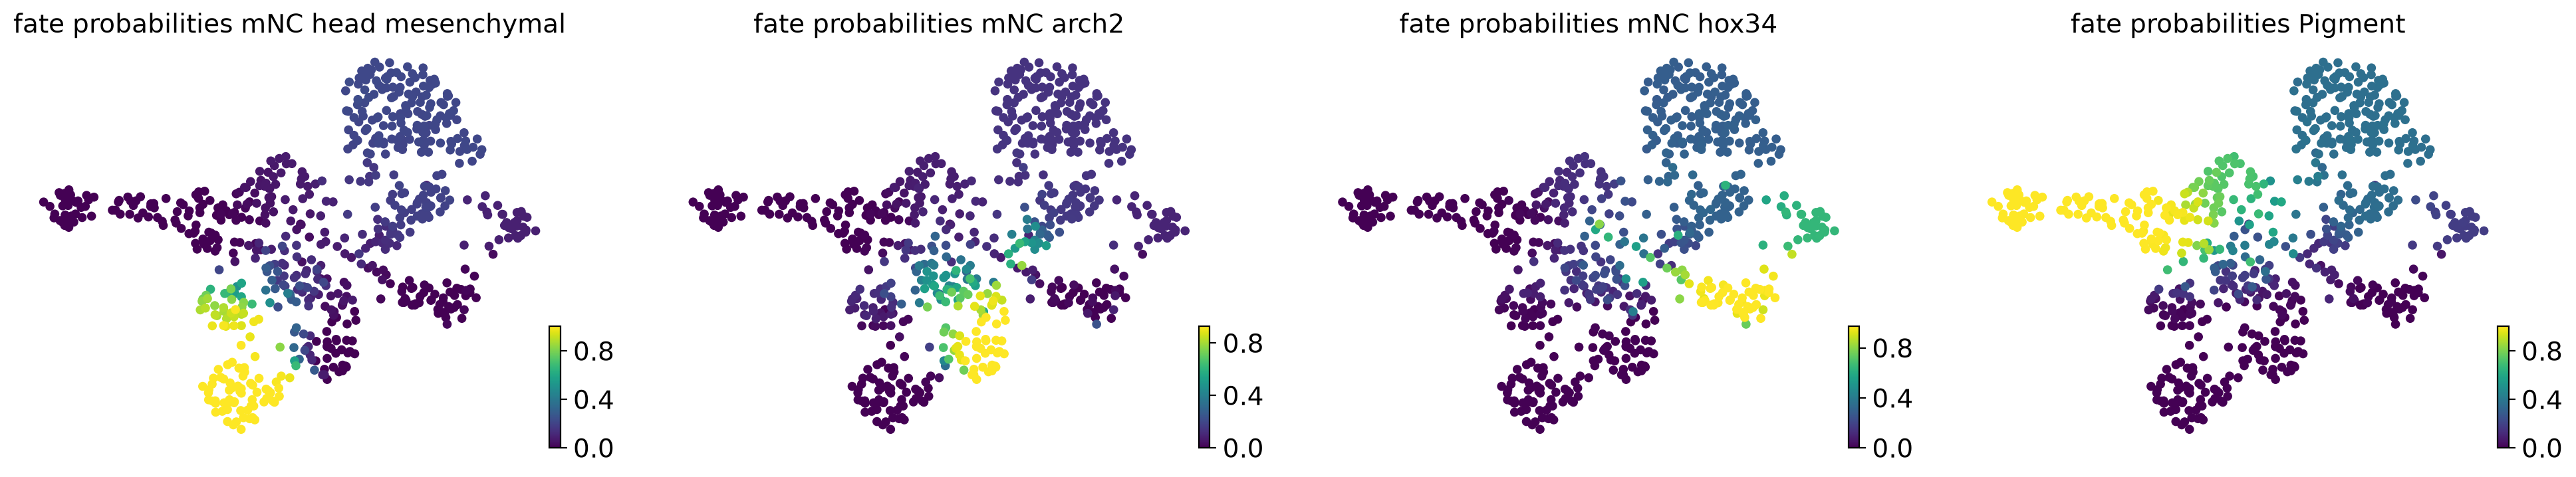

In [18]:
TERMINAL_STATES = ["mNC_head_mesenchymal",
                  "mNC_arch2",
                  "mNC_hox34",
                  "Pigment"]
vk = cr.kernels.VelocityKernel(adata).compute_transition_matrix()
estimator = cr.estimators.GPCCA(vk)

## evaluate the fate prob on original space
estimator.compute_macrostates(n_states=7, cluster_key="cell_type")
estimator.set_terminal_states(TERMINAL_STATES)
estimator.compute_fate_probabilities()
estimator.plot_fate_probabilities(same_plot=False)

/fs/pool/pool-totipotency-software/hpcl67/miniforge_ER/miniforge3/envs/regvelo_paper/lib/python3.11/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/fs/pool/pool-totipotency-software/hpcl67/miniforge_ER/miniforge3/envs/regvelo_paper/lib/python3.11/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/fs/pool/pool-totipotency-software/hpcl67/miniforge_ER/miniforge3/envs/regvelo_paper/lib/python3.11/site-packages/scvelo/plotting/utils.py:1400: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/fs/pool/pool-totipotency-software/hpcl67/miniforge_ER/miniforge3/envs/regvelo_paper/lib/python3.11/site-packages/scvelo/plotting/utils.py:1401: UserWarning: No data for colormap

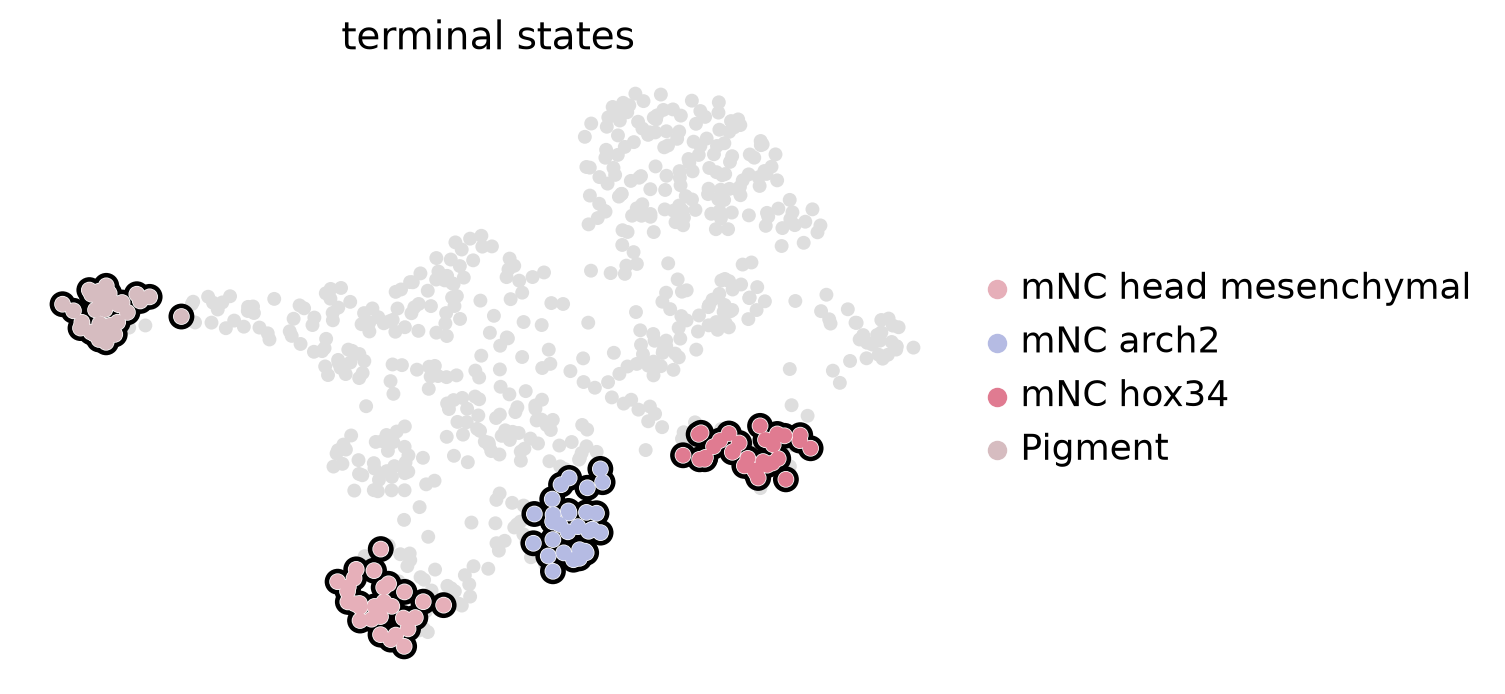

In [19]:
estimator.plot_macrostates(which="terminal", legend_loc="right", s=100)

### Save model

In [20]:
reg_vae.save("rgv_model")

## Perform perturbation screening

In the perturbation screening step, RegVelo enables users to generate a perturbed vector field matrix, which is stored in `adata_target_perturb.layers["velocity"]`. This is then used to construct a new [CellRank](https://www.nature.com/articles/s41592-021-01346-6) kernel, which results in an updated estimate of perturbed cell fate prpobabilities.

We evalute the perturbation effects using two approaches:
<br>
(a) by comparing cell fate probabilities before and after perturbation, and 
<br>
(b) by simulating cell transitions using a Markov chain based on transition matrices inferred from the velocity fields of the unperturbed and perturbed systems.

Let $m$ denote the number of terminal states and $N_C$ the number of cells. For approach (a), we define the *depletion likelihood* to a terminal state $k$ as the normalized Mann-Whitney $U$ statistic 

\begin{equation}
l_d = \frac{1}{N_c^2} \sum_{n=1}^{N_C} \sum_{n^*=1}^{N_C} \mathbb{I} (\Pi_{:,k}(n) > \Pi_{:,k}^*(n^*)),
\end{equation}

where $\mathbb{I}$ is the indicator function and $\Pi, \ \Pi^* \in \mathbb{R}^{N_c \times m}$ are the control and perturbed cell fate probability matrices, respectively. 
For a terminal state $k$, a depletion likelihood $l_d > 0.5$ indicates a long-term depletion effect in the perturbed system, as illustrated in Figure 1 (a). 

It is important to note that the depletion likelihood depends on the long-term fate probabilities of transient cells. In particular, a reduction in a transient cell’s probability of reaching one terminal state must be balanced by an increase in its probability of reaching other terminal states, since the row-wise sums of $\Pi$ and $\Pi^*$ are approximately 1. This redistribution can thus lead to possible long-term enrichment effects in terminal states.

To capture short-term dynamics of the perturbed system, we also simulate the development of progenitor cells over a finite number of steps (``n_steps``) using Markov chain derived from the velocity-based transition matrices of both control and perturbed systems using the function ``rgv.tl.markov_density_simulation``. We then compare the frequency with which terminal cells are reached in both cases, quantifying depletion effects in short-term dynamics (Figure 1(b)). 

The Markov chain simulations can be run with either ``method='stepwise'`` (default) or ``method='one-step'``. The stepwise method simulates transitions one step at a time and terminates each trajectory either upon reaching a terminal cell or after ``n_steps``, whichever comes first. In contrast, the one-step method computes the cell state distribution after ``n_steps`` and draws samples directly from this distribution, without modeling intermediate transitions.

```{figure} _static/perturbation_metrics.svg
:width: 300
:name: fig-perturbation-effects
```

**Figure 1:** Visualization of perturbation effects.  
(a) Depletion likelihood $l_d$ where $\bar{\Pi}_{.k}$ and $\bar{\Pi}^*_{.k}$ denote mean cell fate probabilities.  
(b) Simulated Markov chain transitions of progenitor cells.

In the following, we demonstrate both perturbation quantification approaches for two perturbed models, in which we remove the transcription factors *nr2f5* and *elf1*, respectively.

Terminal states for the perturbed dynamics can be defined in two ways: Either by explicitly setting them via ``estimator.set_terminal_states(TERMINAL_STATES)``, or by reusing the terminal state indices identified in the original dynamics using [CellRank](https://www.nature.com/articles/s41592-021-01346-6).

### Calculating depletion likelihood based on cell fate probability

In [20]:
model = 'rgv_model'

In [21]:
adata_perturb_dict = {}
cand_list = ["nr2f5", "elf1"]

for TF in cand_list:
    model = 'rgv_model'
    adata_target_perturb, reg_vae_perturb =  rgv.tl.in_silico_block_simulation(model=model,
                                                                               adata=adata,
                                                                               TF=TF,
                                                                               cutoff=0)
    adata_perturb_dict[TF] = adata_target_perturb

INFO     File rgv_model/model.pt already downloaded                                                                


/fs/pool/pool-totipotency-software/hpcl67/miniforge_ER/miniforge3/envs/regvelo_paper/lib/python3.11/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/fs/pool/pool-totipotency-software/hpcl67/miniforge_ER/miniforge3/envs/regvelo_paper/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /fs/pool/pool-totipotency-software/hpcl67/miniforge_ ...


INFO     File rgv_model/model.pt already downloaded                                                                


/fs/pool/pool-totipotency-software/hpcl67/miniforge_ER/miniforge3/envs/regvelo_paper/lib/python3.11/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/fs/pool/pool-totipotency-software/hpcl67/miniforge_ER/miniforge3/envs/regvelo_paper/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /fs/pool/pool-totipotency-software/hpcl67/miniforge_ ...


In [22]:
ct_indices = {
    ct: adata.obs["term_states_fwd"][adata.obs["term_states_fwd"] == ct].index.tolist()
    for ct in TERMINAL_STATES}

# Computing states transition probability for perturbed systems
for TF, adata_target_perturb in adata_perturb_dict.items():
    vkp = cr.kernels.VelocityKernel(adata_target_perturb).compute_transition_matrix()
    estimator = cr.estimators.GPCCA(vkp)
    estimator.set_terminal_states(ct_indices)
    estimator.compute_fate_probabilities()

    adata_perturb_dict[TF] = adata_target_perturb

Computing transition matrix using `'deterministic'` model


100%|████████████████████████████████████████████████████| 697/697 [00:00<00:00, 1381.96cell/s]

Using `softmax_scale=10.4414`



[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
100%|████████████████████████████████████████████████████| 697/697 [00:00<00:00, 1526.20cell/s]

    Finish (0:00:01)
Adding `adata.obs['term_states_fwd']`
       `adata.obs['term_states_fwd_probs']`
       `.terminal_states`
       `.terminal_states_probabilities`
       `.terminal_states_memberships
    Finish`
Computing fate probabilities


...

Using `softmax_scale=10.1241`



[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
100%|████████████████████████████████████████████████████| 697/697 [00:00<00:00, 1415.57cell/s]

    Finish (0:00:01)
Adding `adata.obs['term_states_fwd']`
       `adata.obs['term_states_fwd_probs']`
       `.terminal_states`
       `.terminal_states_probabilities`
       `.terminal_states_memberships
    Finish`
Computing fate probabilities



[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
100%|██████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 52.46/s]
[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=ye

Adding `adata.obsm['lineages_fwd']`
       `.fate_probabilities`
    Finish (0:00:00)


In [23]:
df = rgv.mt.cellfate_perturbation(perturbed=adata_perturb_dict, baseline=adata, terminal_state=TERMINAL_STATES)
df

,Depletion likelihood,p-value,FDR adjusted p-value,Terminal state,TF
0,0.556015,0.000147,0.000587,mNC_head_mesenchymal,nr2f5
1,0.499754,0.506344,0.992961,mNC_arch2,nr2f5
2,0.462019,0.992961,0.992961,mNC_hox34,nr2f5
3,0.464504,0.989124,0.992961,Pigment,nr2f5
0,0.472914,0.960024,0.994899,mNC_head_mesenchymal,elf1
1,0.460261,0.994899,0.994899,mNC_arch2,elf1
2,0.472194,0.963875,0.994899,mNC_hox34,elf1
3,0.544160,0.002153,0.008614,Pigment,elf1


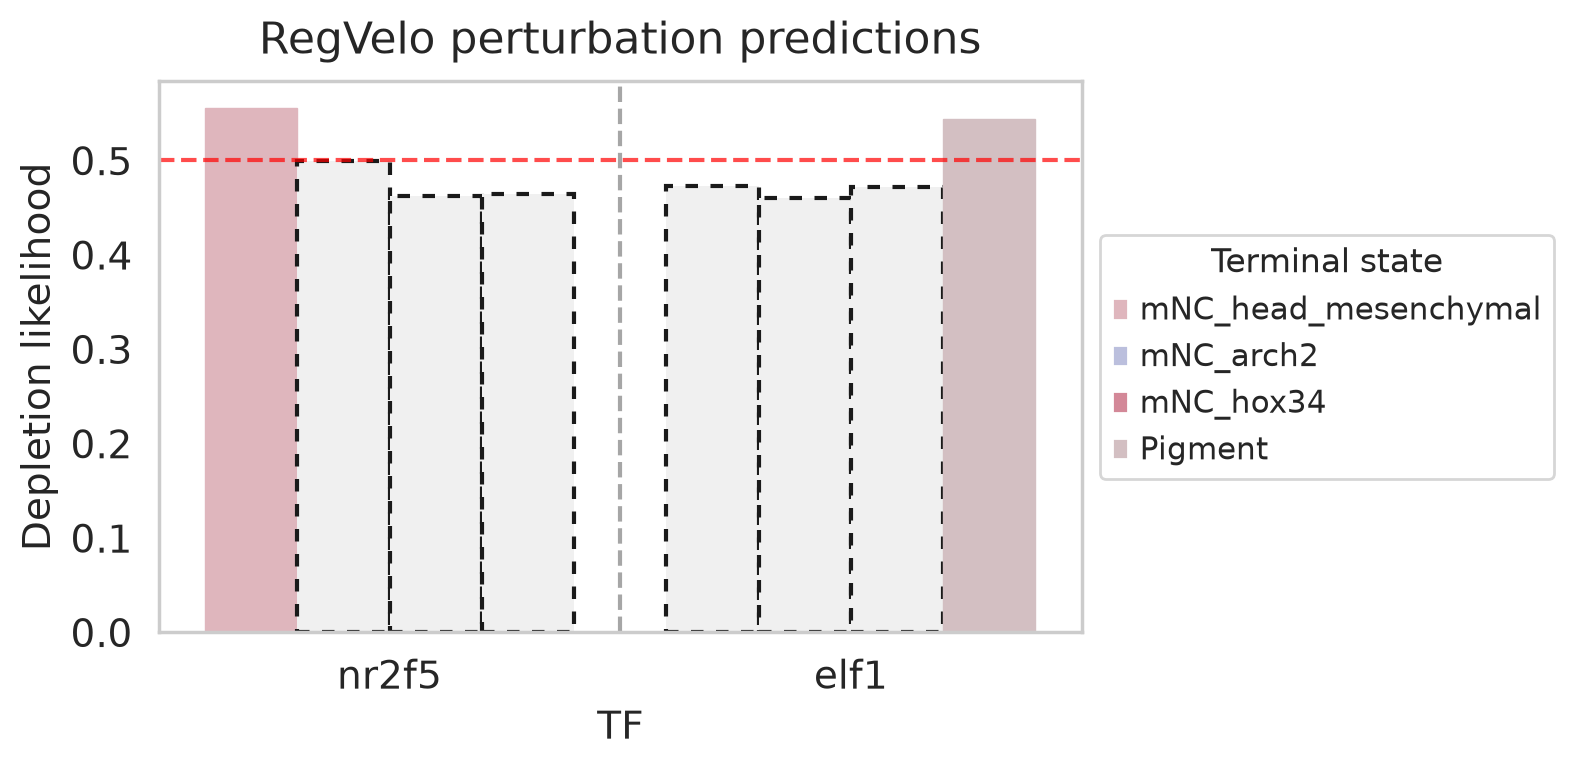

In [24]:
rgv.pl.cellfate_perturbation(adata=adata,
                             df=df,
                             fontsize=14,
                             figsize=(8, 4),
                             legend_loc='center left',
                             legend_bbox=(1.02, 0.5),
                             color_label="cell_type")

By removing the TF *nr2f5*, one would expect a depletion of the cell type *mNC_head_mesenchymal* and an enrichment of the cell types *mNC_arch2*, *mNC_hox34*, and *Pigment* in the long run, compared to the control dynamics.

By removing the TF *elf1*, one would expect a depletion of the cell type *Pigment* and an enrichment of the cell types *mNC_head_mesenchymal*, *mNC_arch2*, and *mNC_hox34* in the long run, compared to the control dynamics.

For both models, we now have a look at their short-term perturbation effects and demonstrate both ``stepwise``and ``one-step`` methods. Transition matrices are computed using [CellRank](https://www.nature.com/articles/s41592-021-01346-6) on the original and perturbed velocity fields.

### Calculating density change likelihood based on stochastic simulations
For the Markov chain simulations, we note that the choice of ``n_steps`` in `rgv.tl.markov_density_simulation` can be made by evaluating the proportion of processes ending in a terminal cell using the control (unperturbed) cell state transition matrix. In this tutorial, we will use the default value ``n_steps=100``.

The function additionally takes as input ``n_simulations``, which determines the number of simulations to be performed for each cell. In this notebook, we will use the default value `n_simulations=1000`.

For the initial state, we select cells of type *NPB_nohox* and determine the `start_indices` and `terminal_indices`, which are required as input for the `rgv.tl.markov_density_simulation` function.

To compare the number of times each terminal cell is visited in the perturbed versus the control model, we compute the difference:
\begin{equation}
\# \text{visits in perturbed model} - \# \text{visits in control model}.
\end{equation}

The absolute and relative number of visits to each terminal cell are stored in `.obs["visits"]` and `.obs["visits_dens"]`, respectively.

For each terminal state, we then use the function `rgv.tl.simulated_density_diff` to compute the average difference in visit counts between the perturbed and unperturbed systems. This function also performs a paired t-test (`scipy.stats.ttest_rel`) to assess whether the number of visits differ significantly between the two systems. The resulting p-values are returned as output.

To visualize short-term perturbation effects, we use the function `rgv.pl.simulated_density_diff`. For each terminal cell, the function computes the difference in the number of visits between the perturbed and control simulations. To account for stochastic variability across simulations, this difference is scaled by $1/\sqrt{\text{\# total simulations}}$. The resulting scaled differences are then passed through a sigmoid function and stored in `adata.obs['visits_diff']`. These scores are further smoothed over neighboring cells to produce a spatially coherent signal, stored in `adata.obs['visits_diff_smoothed']`. Values below 0.5 indicate a relative depletion of visits to the corresponding terminal cell under perturbation.

In [25]:
vk = cr.kernels.VelocityKernel(adata).compute_transition_matrix()
vkt = vk.transition_matrix.A
terminal_indices = np.where(adata.obs["term_states_fwd"].isin(TERMINAL_STATES))[0]
start_indices = np.where(adata.obs["cell_type"].isin(["NPB_nohox"]))[0]

Computing transition matrix using `'deterministic'` model


100%|████████████████████████████████████████████████████| 697/697 [00:00<00:00, 1097.82cell/s]
[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.


Using `softmax_scale=10.0432`


100%|████████████████████████████████████████████████████| 697/697 [00:00<00:00, 1592.49cell/s]
[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.


    Finish (0:00:01)


#### Method 1: Stepwise simulations - *nr2f5* perturbation
We first consider the perturbed model by removing the TF *nr2f5*.

In [26]:
method = "stepwise"

TF = "nr2f5"
adata_perturb = adata_perturb_dict[TF].copy()
adata_perturb.obs["cell_type"] = adata.obs["cell_type"].copy()

vk_p = cr.kernels.VelocityKernel(adata_perturb).compute_transition_matrix()
vkt_p = vk_p.transition_matrix.A

Computing transition matrix using `'deterministic'` model


  0%|          | 0/697 [00:00<?, ?cell/s]

Using `softmax_scale=9.9602`


[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


  0%|          | 0/697 [00:00<?, ?cell/s]

    Finish (0:00:00)


[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


In [27]:
total_simulations = rgv.tl.markov_density_simulation(adata, 
                                                     vkt, 
                                                     start_indices, 
                                                     terminal_indices, 
                                                     TERMINAL_STATES,
                                                     method=method)

_ = rgv.tl.markov_density_simulation(adata_perturb, 
                                     vkt_p, 
                                     start_indices, 
                                     terminal_indices, 
                                     TERMINAL_STATES,
                                     method=method)

In [28]:
dd_score, dd_sig = rgv.tl.simulated_visit_diff(adata, adata_perturb, TERMINAL_STATES)
print(dd_score)
print(dd_sig)

[-79.1, -24.5, -41.400000000000006, -88.29999999999998]
[1.0388254084002412e-07, 6.385268221500673e-07, 6.971348452267312e-10, 0.0004889179271363851]


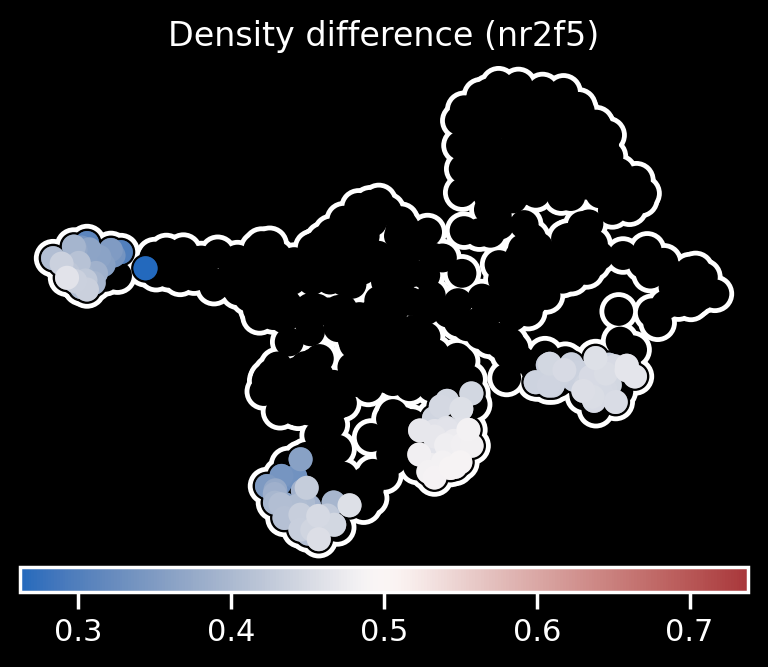

In [29]:
rgv.pl.simulated_visit_diff(adata, 
                            adata_perturb, 
                            TERMINAL_STATES, 
                            total_simulations,
                            title="Density difference (nr2f5)")

We also visualize the distribution of `adata.obs['visits_diff']` for each terminal state using a boxplot. The values are grouped by terminal state and colored according to the p-value from the paired t-test comparing visit counts between the unperturbed and perturbed systems.

In [30]:
df, palette_rel = rgv.tl.visits_diff_perTF(adata, TERMINAL_STATES, dd_sig, SIGNIFICANCE_PALETTE)

mNC_head_mesenchymal: 1.0388254084002412e-07
mNC_arch2: 6.385268221500673e-07
mNC_hox34: 6.971348452267312e-10
Pigment: 0.0004889179271363851


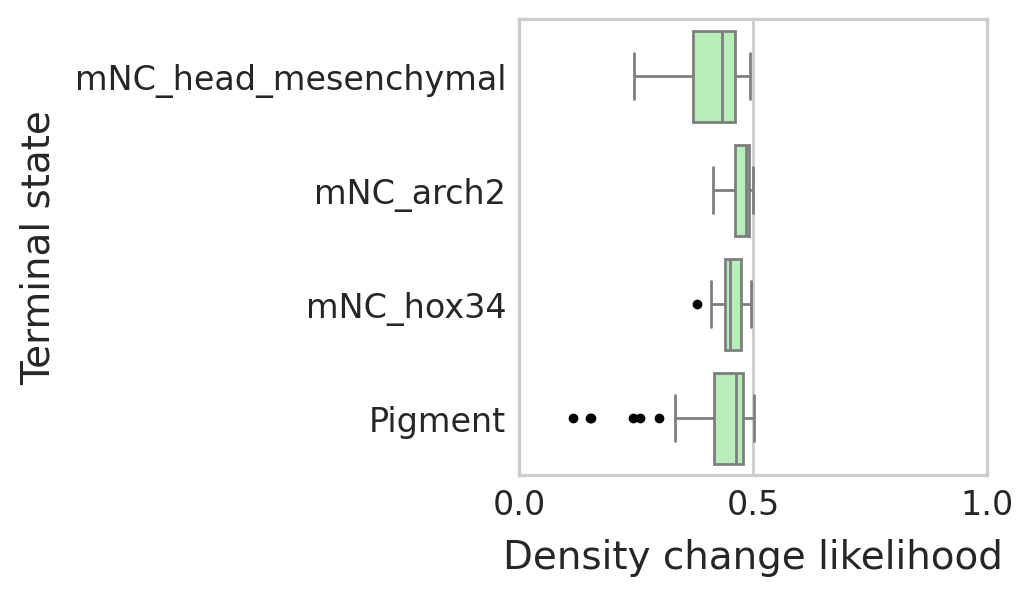

In [31]:
rgv.pl.plot_visits_dist(df, palette_rel, 0.5)

#### Method 1: Stepwise simulations - *elf1* perturbation
We now consider the perturbed model by removing the TF *elf1*. 

In [32]:
del adata.obs['visits']
del adata.obs['visits_dens']
del adata.obs['visits_diff']
del adata.obs['visits_diff_smooth']

In [33]:
TF = "elf1"
adata_perturb = adata_perturb_dict[TF].copy()
adata_perturb.obs["cell_type"] = adata.obs["cell_type"].copy()

vk_p = cr.kernels.VelocityKernel(adata_perturb).compute_transition_matrix()
vkt_p = vk_p.transition_matrix.A

Computing transition matrix using `'deterministic'` model


  0%|          | 0/697 [00:00<?, ?cell/s]

Using `softmax_scale=9.6380`


[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


  0%|          | 0/697 [00:00<?, ?cell/s]

    Finish (0:00:00)


[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


In [34]:
total_simulations = rgv.tl.markov_density_simulation(adata, 
                                                     vkt, 
                                                     start_indices, 
                                                     terminal_indices, 
                                                     TERMINAL_STATES,
                                                     method=method)

_ = rgv.tl.markov_density_simulation(adata_perturb, 
                                     vkt_p, 
                                     start_indices, 
                                     terminal_indices, 
                                     TERMINAL_STATES,
                                     method=method)

In [35]:
dd_score, dd_sig = rgv.tl.simulated_visit_diff(adata, adata_perturb, TERMINAL_STATES)
print(dd_score)
print(dd_sig)

[4.900000000000006, 7.099999999999994, 5.36666666666666, -22.0]
[0.002008393908970593, 0.0008743624255374171, 0.004047887217802147, 0.013239451053673714]


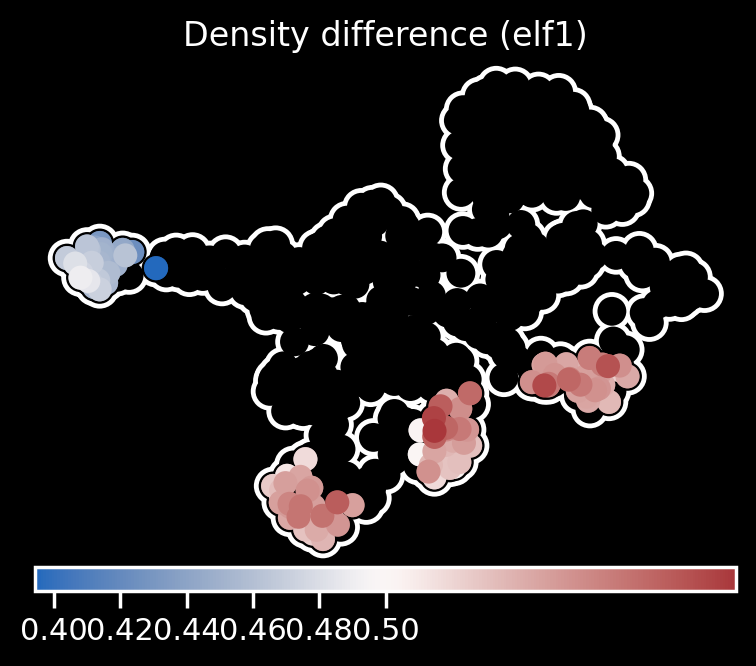

In [36]:
rgv.pl.simulated_visit_diff(adata, 
                            adata_perturb, 
                            TERMINAL_STATES, 
                            total_simulations,
                            title="Density difference (elf1)")

In [37]:
df, palette_rel = rgv.tl.visits_diff_perTF(adata, TERMINAL_STATES, dd_sig, SIGNIFICANCE_PALETTE)

mNC_head_mesenchymal: 0.002008393908970593
mNC_arch2: 0.0008743624255374171
mNC_hox34: 0.004047887217802147
Pigment: 0.013239451053673714


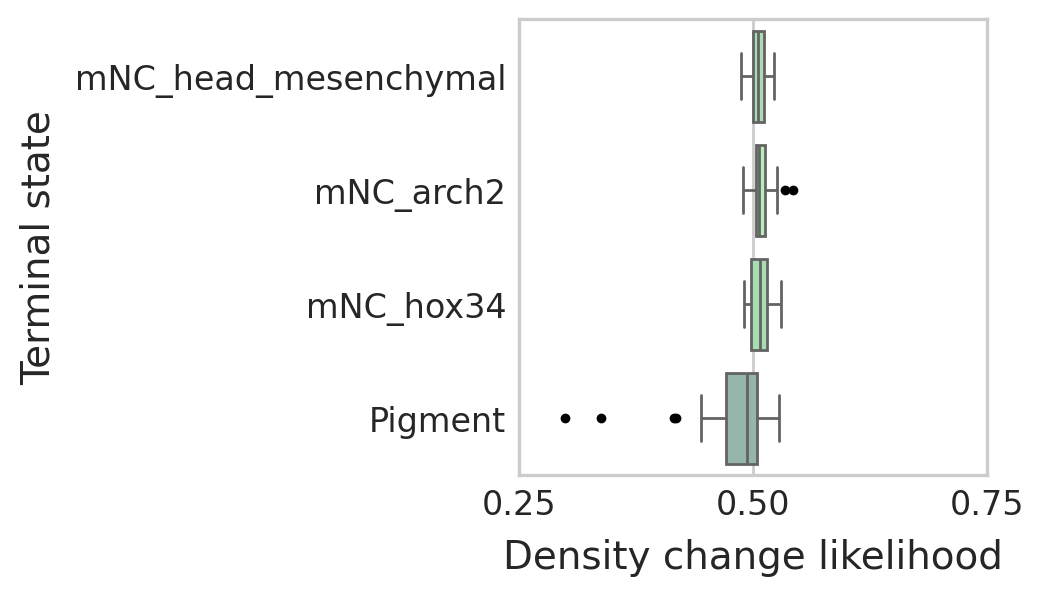

In [38]:
rgv.pl.plot_visits_dist(df, palette_rel, 0.25)

#### Method 2: One-step simulations - *nr2f5* perturbation

In [39]:
del adata.obs['visits']
del adata.obs['visits_dens']
del adata.obs['visits_diff']
del adata.obs['visits_diff_smooth']

In [40]:
method = "one-step"

TF = "nr2f5"
adata_perturb = adata_perturb_dict[TF].copy()
adata_perturb.obs["cell_type"] = adata.obs["cell_type"].copy()

vk_p = cr.kernels.VelocityKernel(adata_perturb).compute_transition_matrix()
vkt_p = vk_p.transition_matrix.A

Computing transition matrix using `'deterministic'` model


  0%|          | 0/697 [00:00<?, ?cell/s]

Using `softmax_scale=9.9602`


[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


  0%|          | 0/697 [00:00<?, ?cell/s]

    Finish (0:00:00)


[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


In [41]:
total_simulations = rgv.tl.markov_density_simulation(adata, 
                                                     vkt, 
                                                     start_indices, 
                                                     terminal_indices, 
                                                     TERMINAL_STATES,
                                                     method=method)

_ = rgv.tl.markov_density_simulation(adata_perturb, 
                                     vkt_p, 
                                     start_indices, 
                                     terminal_indices, 
                                     TERMINAL_STATES,
                                     method=method)

In [42]:
dd_score, dd_sig = rgv.tl.simulated_visit_diff(adata, adata_perturb, TERMINAL_STATES)
print(dd_score)
print(dd_sig)

[-95.23333333333332, -4.600000000000001, -17.433333333333337, -95.46666666666667]
[1.8341934745831434e-05, 0.006290120629851753, 3.731241368483117e-08, 2.9413421676244866e-09]


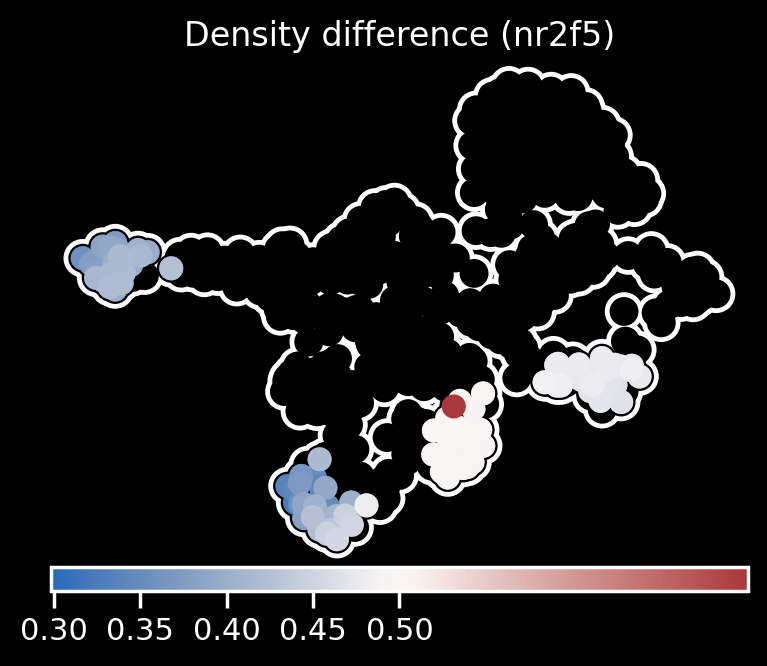

In [43]:
rgv.pl.simulated_visit_diff(adata, 
                            adata_perturb, 
                            TERMINAL_STATES, 
                            total_simulations,
                            title="Density difference (nr2f5)")

In [44]:
df, palette_rel = rgv.tl.visits_diff_perTF(adata, TERMINAL_STATES, dd_sig, SIGNIFICANCE_PALETTE)

mNC_head_mesenchymal: 1.8341934745831434e-05
mNC_arch2: 0.006290120629851753
mNC_hox34: 3.731241368483117e-08
Pigment: 2.9413421676244866e-09


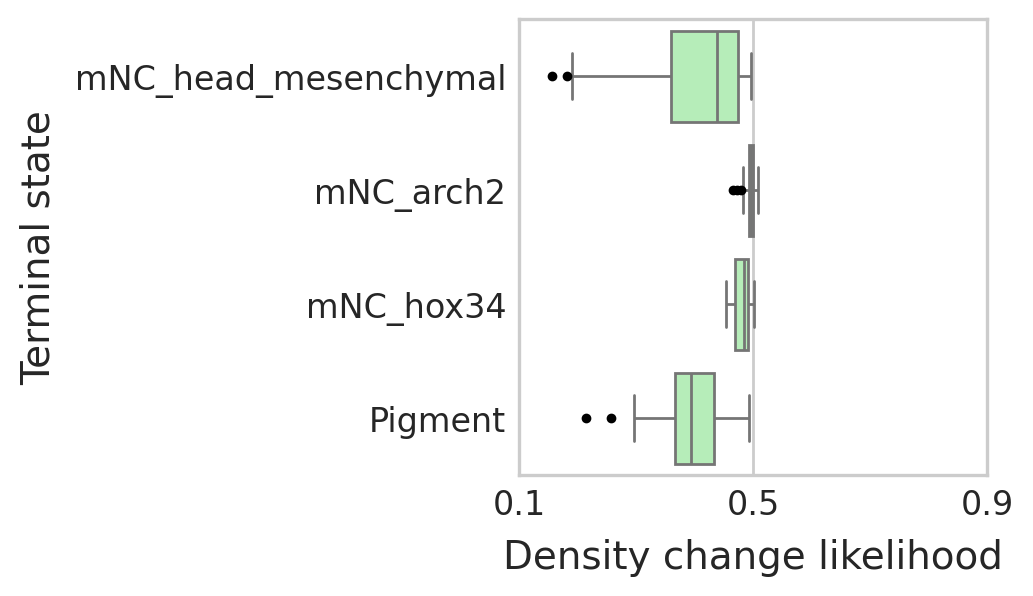

In [45]:
rgv.pl.plot_visits_dist(df, palette_rel, 0.4)

#### Method 2: One-step simulations - *elf1* perturbation

In [46]:
del adata.obs['visits']
del adata.obs['visits_dens']
del adata.obs['visits_diff']
del adata.obs['visits_diff_smooth']

In [47]:
TF = "elf1"
adata_perturb = adata_perturb_dict[TF].copy()
adata_perturb.obs["cell_type"] = adata.obs["cell_type"].copy()

vk_p = cr.kernels.VelocityKernel(adata_perturb).compute_transition_matrix()
vkt_p = vk_p.transition_matrix.A

Computing transition matrix using `'deterministic'` model


  0%|          | 0/697 [00:00<?, ?cell/s]

Using `softmax_scale=9.6380`


[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


  0%|          | 0/697 [00:00<?, ?cell/s]

    Finish (0:00:00)


[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
Abort(59) on node 0 (rank 0 in comm 0): application called MPI_Abort(MPI_COMM_WORLD, 59) - process 0


In [48]:
total_simulations = rgv.tl.markov_density_simulation(adata, 
                                                     vkt, 
                                                     start_indices, 
                                                     terminal_indices, 
                                                     TERMINAL_STATES,
                                                     method=method)

_ = rgv.tl.markov_density_simulation(adata_perturb, 
                                     vkt_p, 
                                     start_indices, 
                                     terminal_indices, 
                                     TERMINAL_STATES,
                                     method=method)

In [49]:
dd_score, dd_sig = rgv.tl.simulated_visit_diff(adata, adata_perturb, TERMINAL_STATES)
print(dd_score)
print(dd_sig)

[11.166666666666686, 1.8000000000000007, 4.0, -25.366666666666674]
[0.002911826078296765, 0.3150595410541873, 0.04884985995147162, 1.3704022023195775e-05]


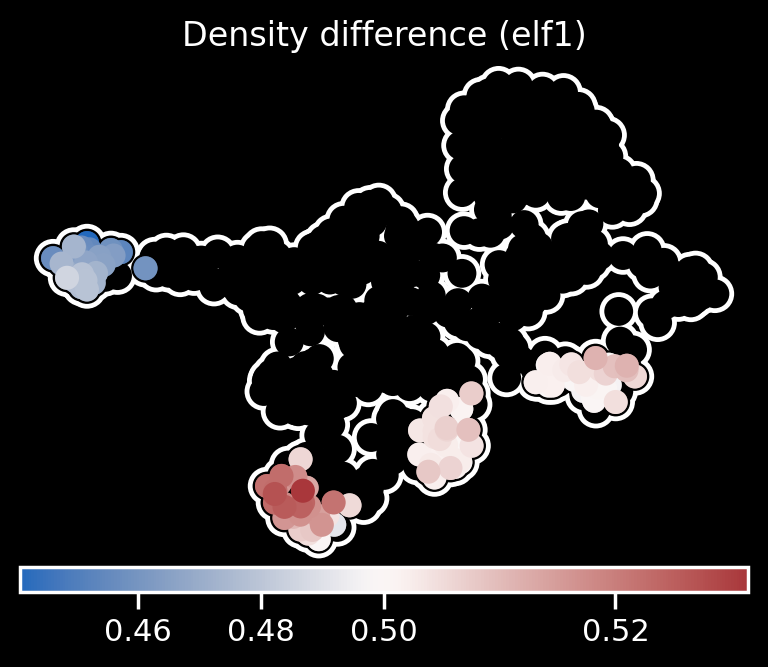

In [50]:
rgv.pl.simulated_visit_diff(adata, 
                            adata_perturb, 
                            TERMINAL_STATES, 
                            total_simulations,
                            title="Density difference (elf1)")

In [51]:
df, palette_rel = rgv.tl.visits_diff_perTF(adata, TERMINAL_STATES, dd_sig, SIGNIFICANCE_PALETTE)

mNC_head_mesenchymal: 0.002911826078296765
mNC_arch2: 0.3150595410541873
mNC_hox34: 0.04884985995147162
Pigment: 1.3704022023195775e-05


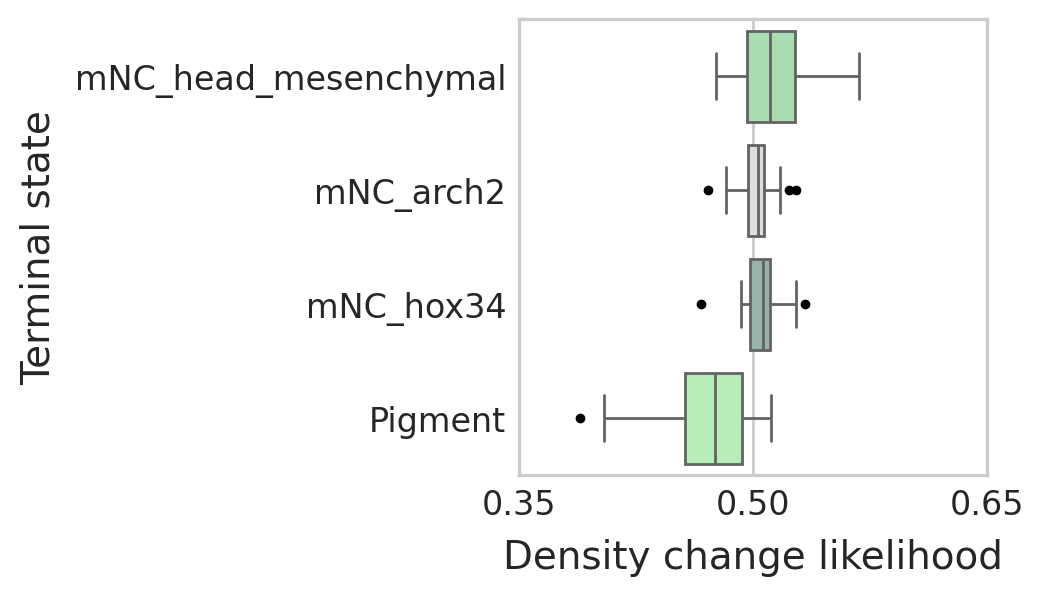

In [52]:
rgv.pl.plot_visits_dist(df, palette_rel, 0.15)

## Screening multiple TFs 

After completing model training and cell fate prediction, users can alternatively perform end-to-end computations for wide-scale TF perturbation screening using the `rgv.tl.markov_density_screening` function. This function allows users to set parameters such as `n_states`. Additionally, setting the `max_nruns` argument (e.g., `max_nruns=5`) enables the model to run multiple times, aggregating perturbation results across runs to improve the robustness and stability of the estimates. By default, the model is run only once. For small datasets, the TF_candidate list can be defined as all detected TFs by using `TF_candidate = TF_list`.

In [30]:
STARTING_POINTS = ["NPB_nohox"]
TF_candidate = ["nr2f5", "elf1"]

rgv.tl.markov_density_screening(adata, adata_perturb_dict,
     TERMINAL_STATES=TERMINAL_STATES,
     STARTING_POINTS=STARTING_POINTS,
     tf_ko_list=TF_candidate,
     cluster_key="cell_type",
     method="stepwise",
     n_step_to_use=500)

100%|█████████████████████████████████████████████████████| 697/697 [00:00<00:00, 988.59cell/s]
[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#valgrind and https://petsc.org/release/faq/
[0]PETSC ERROR: configure using --with-debugging=yes, recompile, link, and run 
[0]PETSC ERROR: to get more information on the crash.
100%|████████████████████████████████████████████████████| 697/697 [00:00<00:00, 1321.57cell/s]
[0]PETSC ERROR: ------------------------------------------------------------------------
[0]PETSC ERROR: Caught signal number 13 Broken Pipe: Likely while reading or writing to a socket
[0]PETSC ERROR: Try option -start_in_debugger or -on_error_attach_debugger
[0]PETSC ERROR: or see https://petsc.org/release/faq/#

Markov simulation complete


After perturbation, the aggregated density likelihood changes are plotted against each terminal state for all transcription factors as a barplot to allow
identification of lineage drivers of each state.

/fs/pool/pool-totipotency-software/hpcl67/miniforge_ER/miniforge3/envs/regvelo_paper/lib/python3.11/site-packages/regvelo/plotting/_plot_visits_dist_screen.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


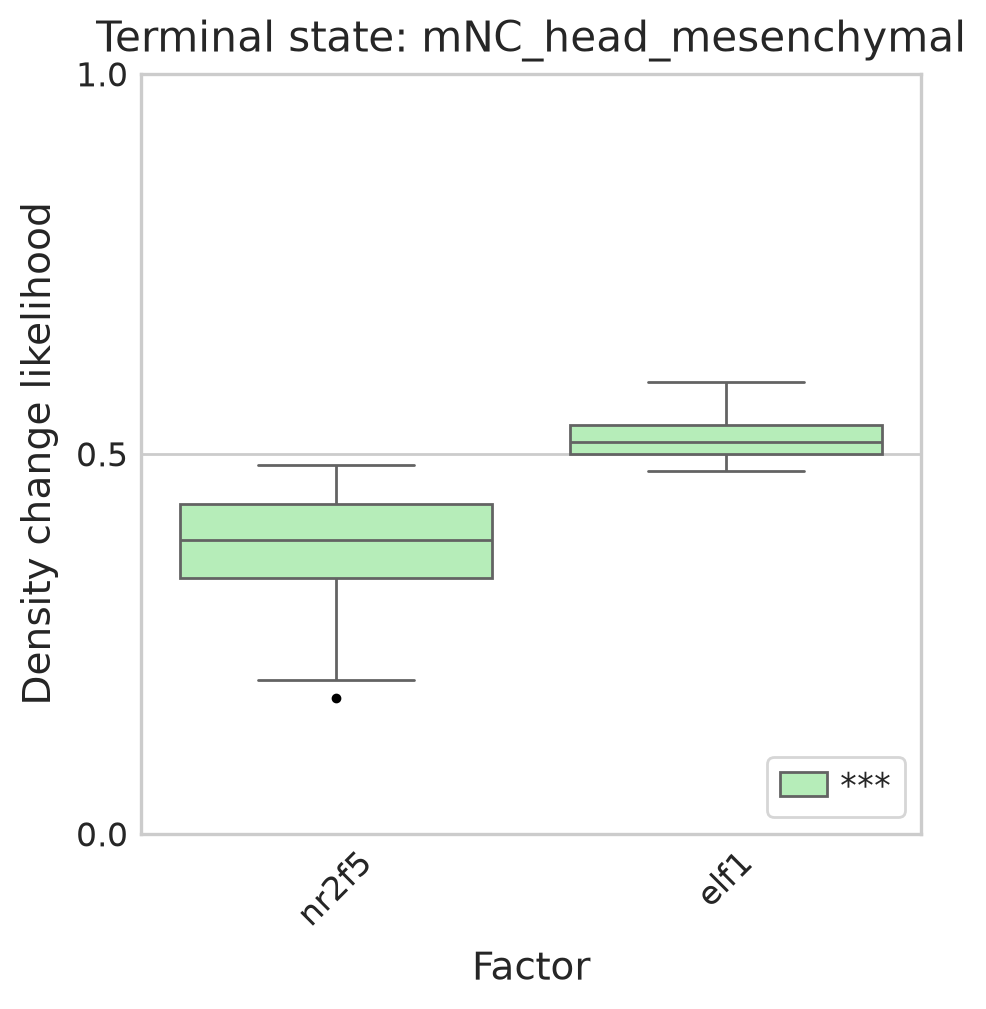

/fs/pool/pool-totipotency-software/hpcl67/miniforge_ER/miniforge3/envs/regvelo_paper/lib/python3.11/site-packages/regvelo/plotting/_plot_visits_dist_screen.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


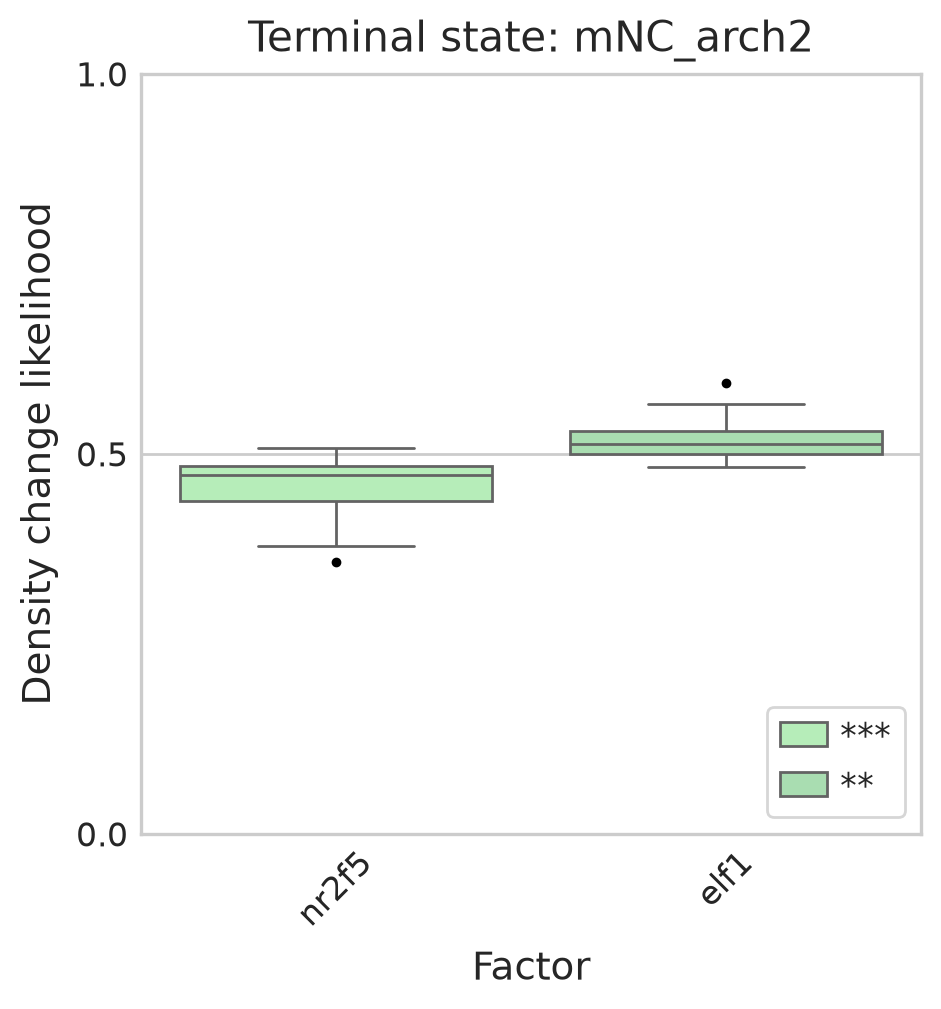

/fs/pool/pool-totipotency-software/hpcl67/miniforge_ER/miniforge3/envs/regvelo_paper/lib/python3.11/site-packages/regvelo/plotting/_plot_visits_dist_screen.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


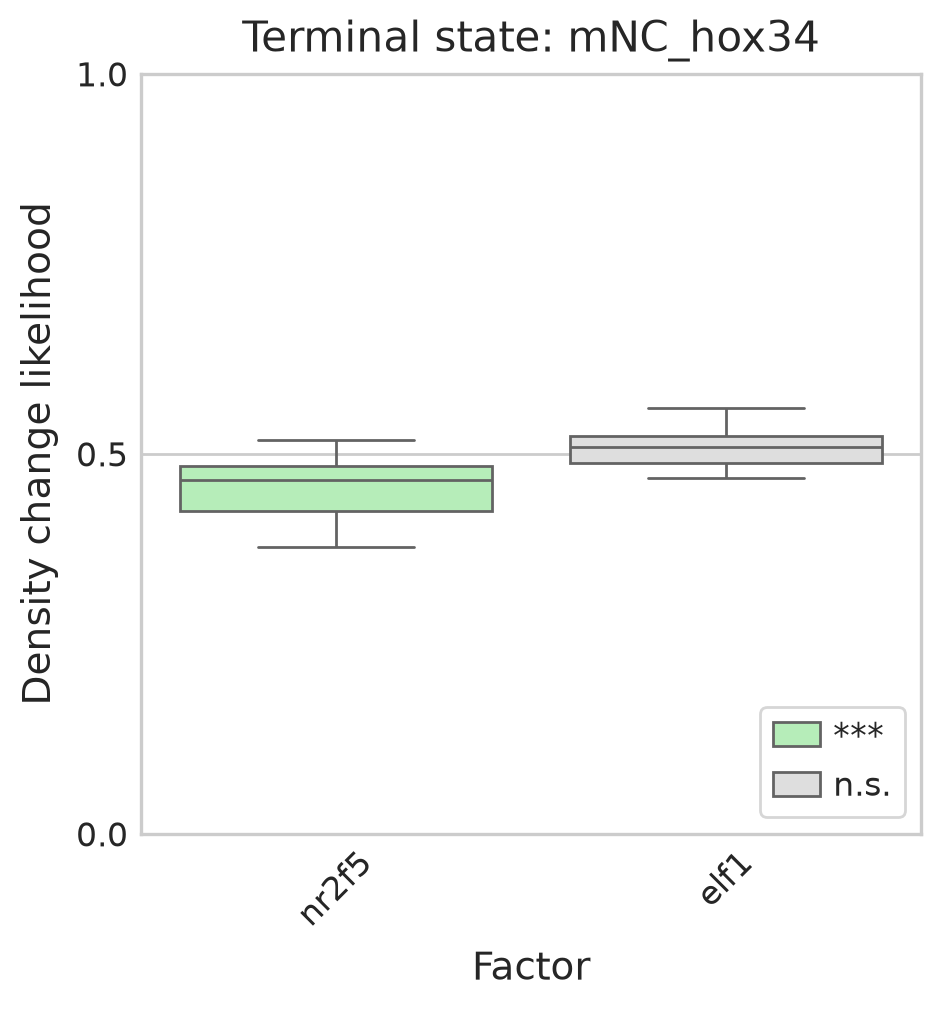

/fs/pool/pool-totipotency-software/hpcl67/miniforge_ER/miniforge3/envs/regvelo_paper/lib/python3.11/site-packages/regvelo/plotting/_plot_visits_dist_screen.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


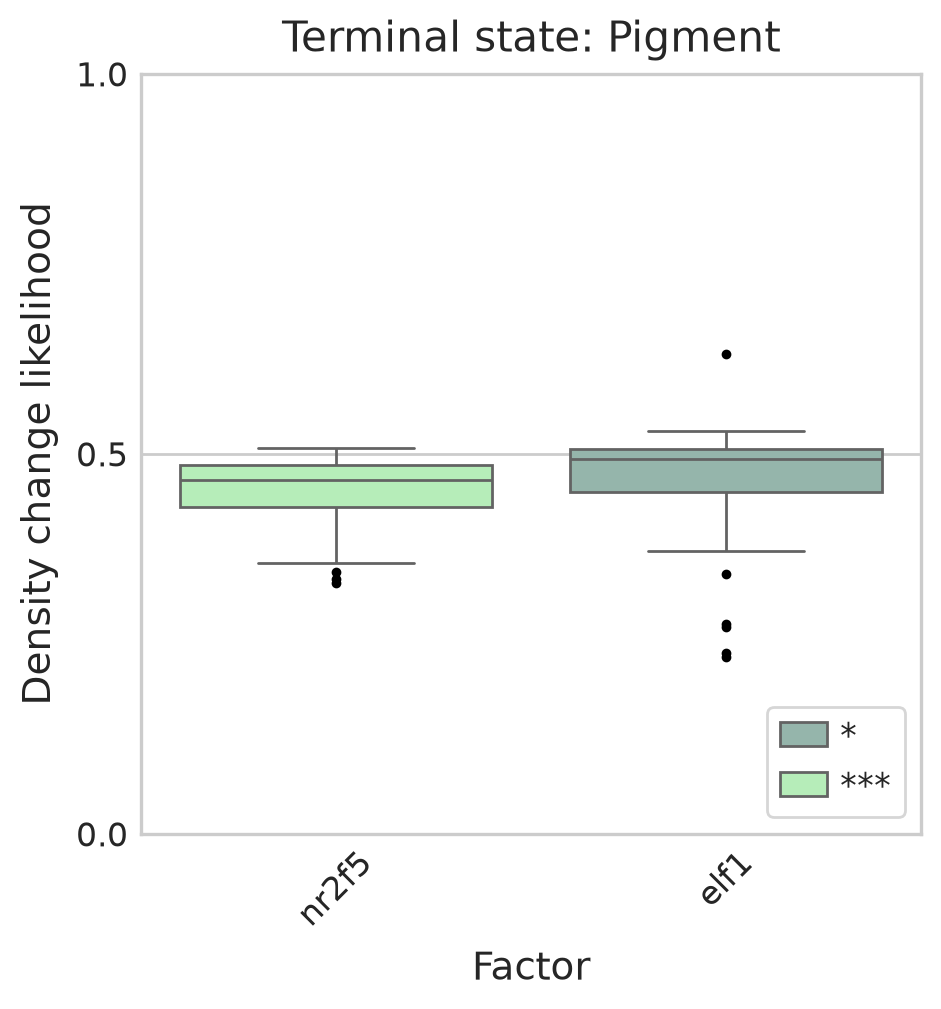

In [31]:
rgv.pl.plot_visits_dist_screen(adata, terminal_states=TERMINAL_STATES, candidate_list=TF_candidate, tick_range=0.5)

We can additionally plot the TFs by ranking the highest relative change in lineage progression over a given trajectory which is quantified as:

Δ success rate = (perturbed rate / control rate) – 1

where perturbed rate and control rate are the sums of density normalized visit counts in each system. 
This metric indicates whether the knockout disrupts normal differentiation toward the terminal states as a fraction. 
Negative values indicate fewer cells complete the trajectory after knockout (the TF is required for normal differentiation), 
while positive values indicate more cells reach the terminal states (the knockout promotes differentiation).


/fs/pool/pool-totipotency-software/hpcl67/miniforge_ER/miniforge3/envs/regvelo_paper/lib/python3.11/site-packages/regvelo/plotting/_plot_TF_success_rate.py:88: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


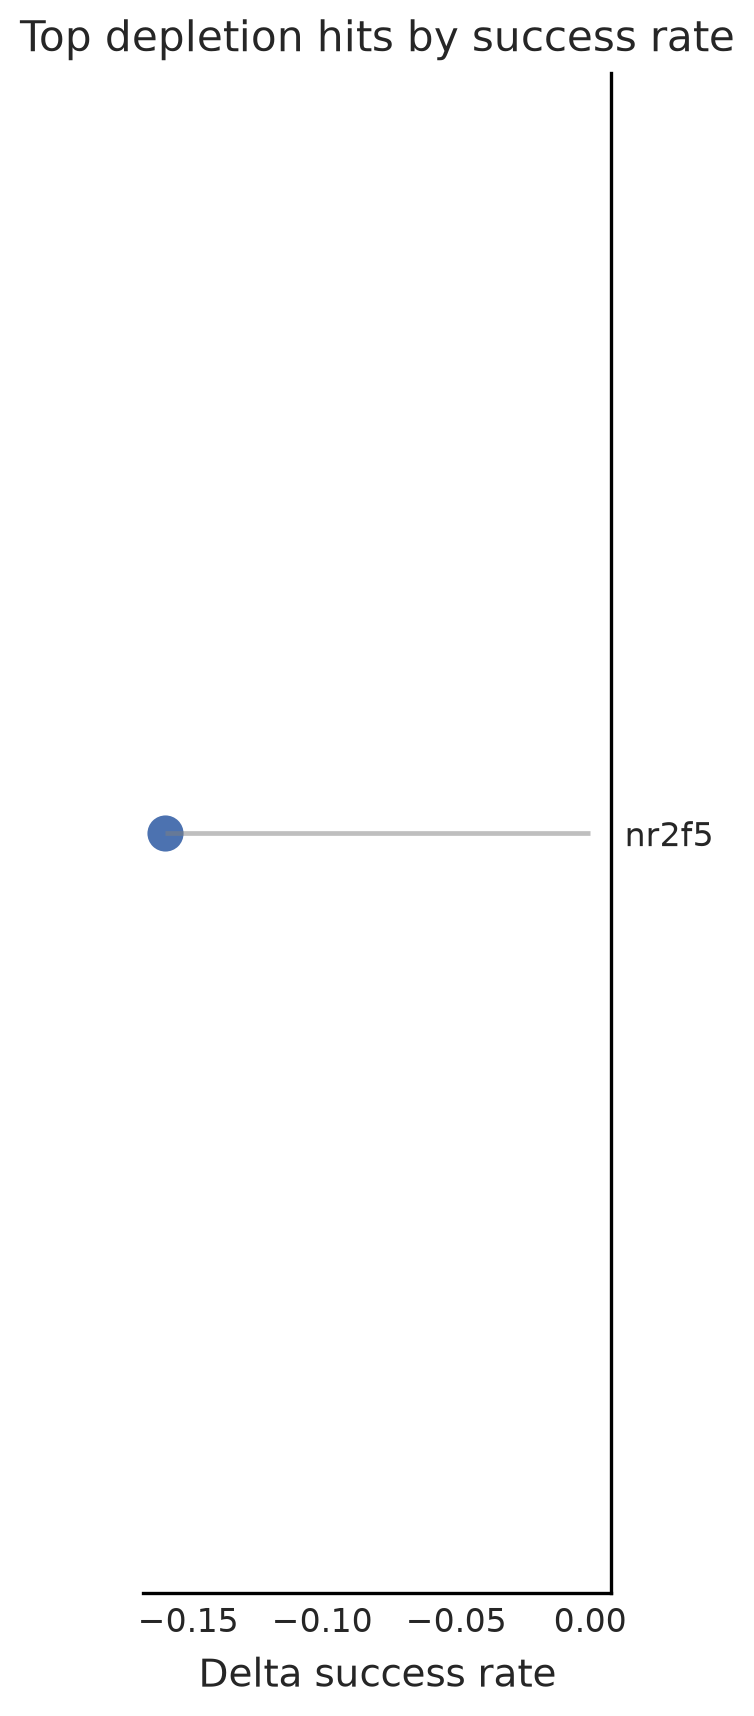

/fs/pool/pool-totipotency-software/hpcl67/miniforge_ER/miniforge3/envs/regvelo_paper/lib/python3.11/site-packages/regvelo/plotting/_plot_TF_success_rate.py:118: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


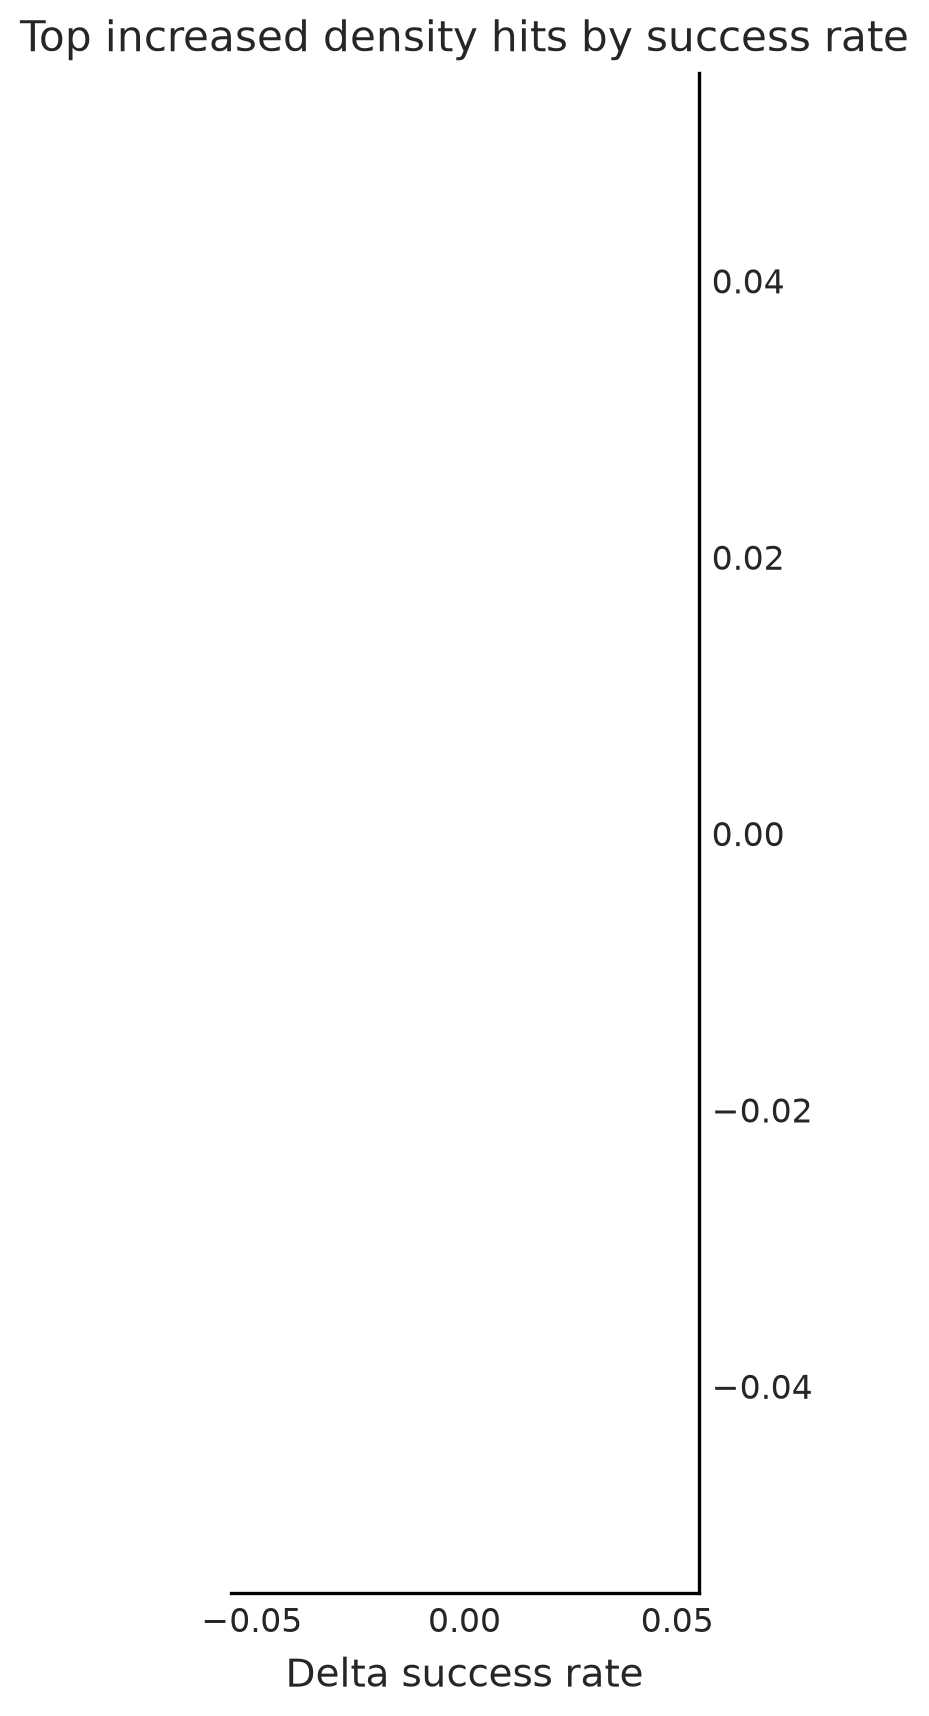

In [32]:
rgv.pl.plot_TF_success_rate(adata, threshold=0.1)